In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Load preprocessed data



In [22]:
df_preprocessed = pd.read_csv("/content/preprocessed_lung_cancer_data.csv")

display(df_preprocessed.shape)

(100211, 41)

## Split data



In [23]:
from sklearn.model_selection import train_test_split

features = df_preprocessed.drop(columns=['id', 'diagnosis_date', 'end_treatment_date', 'survived'])
target = df_preprocessed['survived']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)

# Print the shapes of the training and testing sets
print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (80168, 37)
Shape of X_test: (20043, 37)
Shape of y_train: (80168,)
Shape of y_test: (20043,)


## Train and evaluate without hyperparameter tuning



Evaluation Metrics (Without Imbalance Handling):
Accuracy: 0.7797
Precision: 0.2400
Recall: 0.0027
F1 Score: 0.0054


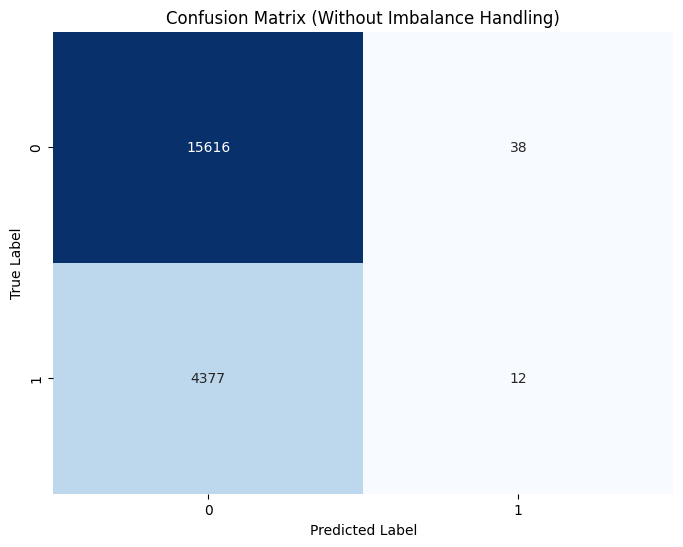

In [24]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Instantiate a GaussianNB model
model_no_imbalance = GaussianNB()

# Train the model
model_no_imbalance.fit(X_train, y_train)

# Make predictions
y_pred_no_imbalance = model_no_imbalance.predict(X_test)

# Evaluate the model
accuracy_no_imbalance = accuracy_score(y_test, y_pred_no_imbalance)
precision_no_imbalance = precision_score(y_test, y_pred_no_imbalance)
recall_no_imbalance = recall_score(y_test, y_pred_no_imbalance)
f1_no_imbalance = f1_score(y_test, y_pred_no_imbalance)

# Print evaluation metrics
print("Evaluation Metrics (Without Imbalance Handling):")
print(f"Accuracy: {accuracy_no_imbalance:.4f}")
print(f"Precision: {precision_no_imbalance:.4f}")
print(f"Recall: {recall_no_imbalance:.4f}")
print(f"F1 Score: {f1_no_imbalance:.4f}")

# Generate and visualize the confusion matrix
cm_no_imbalance = confusion_matrix(y_test, y_pred_no_imbalance)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_no_imbalance, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix (Without Imbalance Handling)')
plt.show()

## Handle class imbalance




In [25]:
# Calculate class priors
class_priors = y_train.value_counts(normalize=True).sort_index()

# Instantiate a GaussianNB model with class priors
model_with_imbalance = GaussianNB(priors=class_priors.values)

# Train the model
model_with_imbalance.fit(X_train, y_train)

print("Naive Bayes model trained with class priors to address imbalance.")

Naive Bayes model trained with class priors to address imbalance.


## Train and evaluate with hyperparameter tuning




Evaluation Metrics (With Imbalance Handling):
Accuracy: 0.7797
Precision: 0.2400
Recall: 0.0027
F1 Score: 0.0054


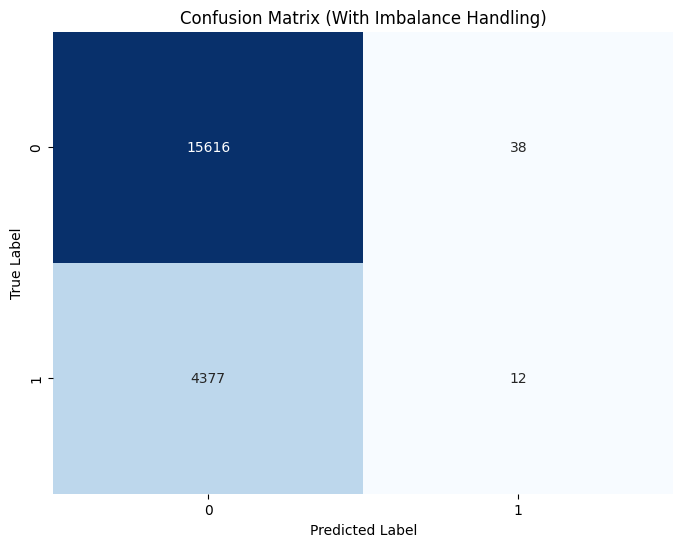

In [26]:
# Make predictions on the test set
y_pred_with_imbalance = model_with_imbalance.predict(X_test)

# Evaluate the performance with imbalance handling
accuracy_with_imbalance = accuracy_score(y_test, y_pred_with_imbalance)
precision_with_imbalance = precision_score(y_test, y_pred_with_imbalance)
recall_with_imbalance = recall_score(y_test, y_pred_with_imbalance)
f1_with_imbalance = f1_score(y_test, y_pred_with_imbalance)

# Print evaluation metrics with imbalance handling
print("Evaluation Metrics (With Imbalance Handling):")
print(f"Accuracy: {accuracy_with_imbalance:.4f}")
print(f"Precision: {precision_with_imbalance:.4f}")
print(f"Recall: {recall_with_imbalance:.4f}")
print(f"F1 Score: {f1_with_imbalance:.4f}")

# Generate and visualize the confusion matrix
cm_with_imbalance = confusion_matrix(y_test, y_pred_with_imbalance)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_with_imbalance, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix (With Imbalance Handling)')
plt.show()